In [ ]:
import zipfile

zip_path = r"C:\Users\Jatin\Desktop\cat_dog_prediction\archive.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("dataset")

In [2]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

In [3]:
X = []
y = []

cat_path = "dataset/animals/cat"
dog_path = "dataset/animals/dog"

In [4]:
for image_name in os.listdir(cat_path):
    image_path = os.path.join(cat_path, image_name)
    image = Image.open(image_path).convert("RGB")
    image = image.resize((128, 128))
    image = np.array(image)

    X.append(image)
    y.append(0)

In [5]:
for image_name in os.listdir(dog_path):
    image_path = os.path.join(dog_path, image_name)
    image = Image.open(image_path).convert("RGB")
    image = image.resize((128, 128))
    image = np.array(image)

    X.append(image)
    y.append(1)

In [6]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(999, 128, 128, 3)
(999,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
X_train = X_train / 255.0
X_test = X_test / 255.0

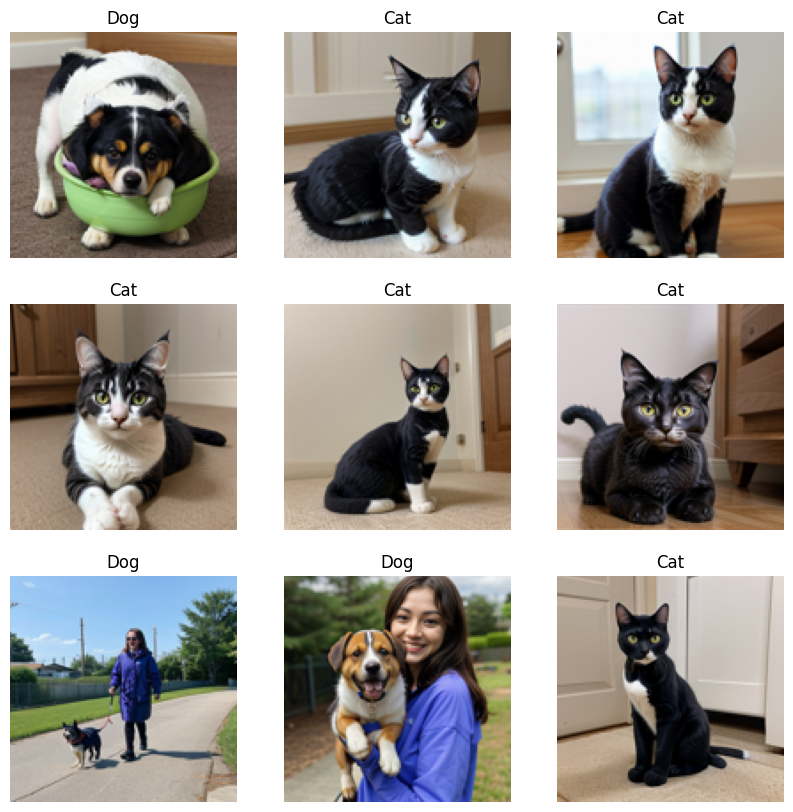

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i])
    plt.title("Dog" if y_train[i] == 1 else "Cat")
    plt.axis("off")

plt.show()

In [10]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [11]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

#MobileNetV2 model
mobilenet_base = MobileNetV2(input_shape=(128, 128, 3),
                              include_top=False,
                              weights='imagenet')

# Freeze the base model to prevent its weights from being updated during training
mobilenet_base.trainable = False

model = Sequential([
    mobilenet_base,
    GlobalAveragePooling2D(),

    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [12]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 402ms/step - accuracy: 0.9750 - loss: 0.0491 - val_accuracy: 1.0000 - val_loss: 1.8298e-04
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 280ms/step - accuracy: 1.0000 - loss: 1.0174e-04 - val_accuracy: 1.0000 - val_loss: 9.3278e-06
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 277ms/step - accuracy: 1.0000 - loss: 5.5406e-05 - val_accuracy: 1.0000 - val_loss: 9.2894e-06
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 336ms/step - accuracy: 1.0000 - loss: 8.4341e-05 - val_accuracy: 1.0000 - val_loss: 1.2802e-05
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 282ms/step - accuracy: 1.0000 - loss: 3.0040e-05 - val_accuracy: 1.0000 - val_loss: 1.0541e-05
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 313ms/step - accuracy: 1.0000 - loss: 4.5285e-05 - val_accuracy: 1.0000 - val_loss: 1.5756e-05
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 266ms/step - accuracy: 1.0000 - loss: 2.6602e-05 - val_accuracy: 1.0000 - val_loss: 1.1422e-05
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 352ms/ste

### Fine-tuning the MobileNetV2 base

Now we will unfreeze some layers of the `mobilenet_base` and continue training the model with a very low learning rate. This allows the pre-trained weights to adapt more specifically to our dataset.

In [15]:
# Unfreeze the base model
mobilenet_base.trainable = True

for layer in mobilenet_base.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,914,369 (11.12 MB)

 Trainable params: 2,517,825 (9.60 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [16]:
history_fine_tune = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 533ms/step - accuracy: 0.9734 - loss: 0.0864 - val_accuracy: 1.0000 - val_loss: 1.9575e-06
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 429ms/step - accuracy: 0.9906 - loss: 0.0249 - val_accuracy: 1.0000 - val_loss: 9.4606e-07
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 445ms/step - accuracy: 0.9953 - loss: 0.0121 - val_accuracy: 1.0000 - val_loss: 6.5260e-07
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 487ms/step - accuracy: 0.9937 - loss: 0.0208 - val_accuracy: 1.0000 - val_loss: 6.9038e-07
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 488ms/step - accuracy: 0.9984 - loss: 0.0106 - val_accuracy: 1.0000 - val_loss: 6.5762e-07
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 543ms/step - accuracy: 0.9969 - loss: 0.0054 - val_accuracy: 1.0000 - val_loss: 6.1243e-07
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 443ms/step - accuracy: 0.9969 - loss: 0.0084 - val_accuracy: 1.0000 - val_loss: 5.5096e-07
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 450ms/step - accuracy: 0.9969

In [17]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step - accuracy: 1.0000 - loss: 4.1050e-05
Test Accuracy: 1.0


In [18]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Make predictions
y_pred_prob = model.predict(X_test)

# Convert probabilities to 0 or 1
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Precision, Recall, F1-score
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Cat", "Dog"]
))

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 326ms/step
Accuracy: 1.0

Confusion Matrix:
[[100   0]
 [  0 100]]

Classification Report:
              precision    recall  f1-score   support

         Cat       1.00      1.00      1.00       100
         Dog       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
model.save("cat_dog_mobilenetv2.h5")